# 02 — Factores de riesgo modificables con SQL

**Proyecto:** BRFSS 2015 — Análisis SQL de Riesgo de Diabetes  
**Repositorio:** https://github.com/Jesusrodriguezf90/brfss2015-diabetes-sql-analysis  
**Fase:** Análisis de factores de riesgo modificables

---

Análisis de los factores de riesgo modificables asociados a la diabetes mediante CTEs y subqueries.
Se cuantifica el impacto de dieta, actividad física y comorbilidades sobre la prevalencia,
cruzando variables clínicas con la variable objetivo `DIABETE3`.

> **Nota sobre `BPHIGH4`:** variable nominal con cuatro valores — solo el valor `1` (Sí, hipertensión)
> se considera positivo. Los valores `2` (solo embarazo), `3` (No) y `4` (borderline) se excluyen
> del indicador binario para mantener la precisión clínica.

In [ ]:
"""
Notebook: 02_risk_factors_sql.ipynb

Objetivo:
    Cuantificar el impacto de los factores de riesgo modificables sobre
    la prevalencia de diabetes mediante CTEs y subqueries en DuckDB.
    Incluye análisis de dieta, ejercicio, actividad física y comorbilidades.

Autor:   Jesús Rodríguez
Fecha:   2026-06-11
Versión: 1.0.0
"""

## 0. Setup

In [7]:
# Importaciones
import warnings

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Estilo global de visualizaciones
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print(f'DuckDB {duckdb.__version__} | pandas {pd.__version__}')

DuckDB 1.5.3 | pandas 3.0.3


In [8]:
# URL pública del dataset preprocesado en HF Hub
URL_DATASET = 'hf://datasets/Jesusrodriguezf90/brfss2015-diabetes-detection/cleaned_dataset.csv'

# Carga del dataset y registro en DuckDB
df  = pd.read_csv(URL_DATASET)
con = duckdb.connect()
con.register('brfss', df)

print(f'[OK] Dataset cargado: {df.shape[0]:,} registros · {df.shape[1]} columnas')

[OK] Dataset cargado: 257,709 registros · 23 columnas


## 1. Delta de medias entre clases — dieta y ejercicio

Cuantificación de la diferencia de medias entre población diabética y no diabética
para las variables continuas de dieta y ejercicio.
Se usa una CTE para calcular las medias por clase y una subquery para calcular el delta,
ordenado por impacto absoluto descendente.

> **Nota sobre `EXEROFT1`:** los diabéticos muestran una frecuencia de ejercicio
> ligeramente *superior* a los no diabéticos. Este resultado contraintuitivo es consistente
> con la literatura — los pacientes diabéticos diagnosticados reciben indicación médica
> de ejercicio físico como parte del tratamiento.

In [9]:
# Delta de medias entre diabéticos y no diabéticos para variables continuas
# Dos CTEs: medias_por_clase calcula medias por clase, resultados construye el UNION ALL
# La subquery exterior permite ORDER BY ABS(delta) sobre el resultado del UNION
resultado_delta = con.execute("""
    WITH medias_por_clase AS (
        SELECT
            CASE WHEN DIABETE3 = 1.0 THEN 'Diabético' ELSE 'No diabético' END AS clase,
            ROUND(AVG(_FRUTSUM),  3) AS media_fruta,
            ROUND(AVG(_VEGESUM),  3) AS media_verdura,
            ROUND(AVG(EXEROFT1),  3) AS media_ejercicio
        FROM brfss
        GROUP BY DIABETE3
    ),
    resultados AS (
        SELECT
            'Fruta (porciones/día)'       AS variable,
            MAX(CASE WHEN clase = 'Diabético'    THEN media_fruta     END) AS media_diabeticos,
            MAX(CASE WHEN clase = 'No diabético' THEN media_fruta     END) AS media_no_diabeticos,
            ROUND(
                MAX(CASE WHEN clase = 'Diabético'    THEN media_fruta END) -
                MAX(CASE WHEN clase = 'No diabético' THEN media_fruta END), 3
            )                                                               AS delta
        FROM medias_por_clase
        UNION ALL
        SELECT
            'Verdura (porciones/día)',
            MAX(CASE WHEN clase = 'Diabético'    THEN media_verdura   END),
            MAX(CASE WHEN clase = 'No diabético' THEN media_verdura   END),
            ROUND(
                MAX(CASE WHEN clase = 'Diabético'    THEN media_verdura END) -
                MAX(CASE WHEN clase = 'No diabético' THEN media_verdura END), 3
            )
        FROM medias_por_clase
        UNION ALL
        SELECT
            'Ejercicio (veces/semana)',
            MAX(CASE WHEN clase = 'Diabético'    THEN media_ejercicio END),
            MAX(CASE WHEN clase = 'No diabético' THEN media_ejercicio END),
            ROUND(
                MAX(CASE WHEN clase = 'Diabético'    THEN media_ejercicio END) -
                MAX(CASE WHEN clase = 'No diabético' THEN media_ejercicio END), 3
            )
        FROM medias_por_clase
    )
    SELECT * FROM resultados
    ORDER BY ABS(delta) DESC
""").df()

print('-' * 70)
print(f"{'Variable':<26} {'Diabéticos':>12} {'No diabéticos':>15} {'Delta':>10}")
print('-' * 70)
for _, row in resultado_delta.iterrows():
    print(f"{row['variable']:<26} {row['media_diabeticos']:>12.3f} {row['media_no_diabeticos']:>15.3f} {row['delta']:>10.3f}")
print('-' * 70)

----------------------------------------------------------------------
Variable                     Diabéticos   No diabéticos      Delta
----------------------------------------------------------------------
Verdura (porciones/día)           1.913           2.088     -0.175
Fruta (porciones/día)             1.330           1.465     -0.135
Ejercicio (veces/semana)          4.112           4.008      0.104
----------------------------------------------------------------------


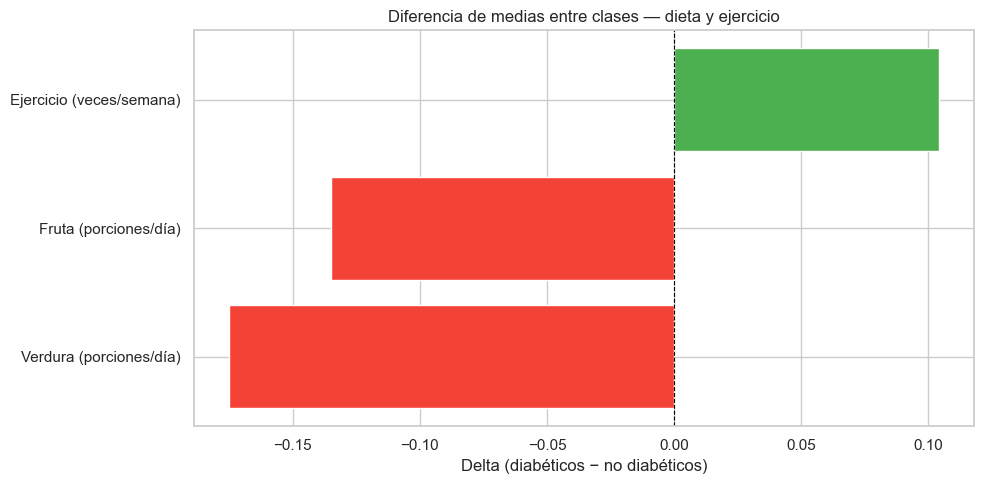

In [10]:
# Visualización del delta por variable — negativo = menor consumo en diabéticos
colores = ['#F44336' if d < 0 else '#4CAF50' for d in resultado_delta['delta']]
fig, ax = plt.subplots()
ax.barh(resultado_delta['variable'], resultado_delta['delta'], color=colores)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Delta (diabéticos − no diabéticos)')
ax.set_title('Diferencia de medias entre clases — dieta y ejercicio')
plt.tight_layout()
plt.show()

## 2. Prevalencia por actividad física × IMC

Tabla de contingencia SQL — prevalencia de diabetes cruzando categoría de actividad
física (`_PACAT1`) con categoría de IMC (`_BMI5CAT`).
Se filtran los valores `-1` de `_PACAT1`. `_BMI5CAT` no tiene valores inválidos.

In [12]:
# Tabla de contingencia: prevalencia de diabetes por actividad física x IMC
# JOIN sobre agregados para cruzar las dos dimensiones
resultado_pacat_bmi = con.execute("""
    SELECT
        CASE _PACAT1
            WHEN 1 THEN 'Muy activo'
            WHEN 2 THEN 'Activo'
            WHEN 3 THEN 'Insuf. activo'
            WHEN 4 THEN 'Inactivo'
        END                                                              AS actividad_fisica,
        CASE _BMI5CAT
            WHEN 1 THEN 'Bajo peso'
            WHEN 2 THEN 'Peso normal'
            WHEN 3 THEN 'Sobrepeso'
            WHEN 4 THEN 'Obesidad'
        END                                                              AS categoria_imc,
        _PACAT1                                                          AS orden_pacat,
        _BMI5CAT                                                         AS orden_bmi,
        COUNT(*)                                                         AS n_total,
        ROUND(
            SUM(CASE WHEN DIABETE3 = 1.0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1
        )                                                                AS prevalencia_pct
    FROM brfss
    WHERE _PACAT1 != -1.0
    GROUP BY _PACAT1, _BMI5CAT
    ORDER BY _PACAT1, _BMI5CAT
""").df()

print('-' * 65)
print(f"{'Actividad física':<16} {'IMC':<12} {'N total':>10} {'Prevalencia':>12}")
print('-' * 65)
for _, row in resultado_pacat_bmi.iterrows():
    print(f"{row['actividad_fisica']:<16} {row['categoria_imc']:<12} {int(row['n_total']):>10,} {row['prevalencia_pct']:>11.1f}%")
print('-' * 65)

-----------------------------------------------------------------
Actividad física IMC             N total  Prevalencia
-----------------------------------------------------------------
Muy activo       Bajo peso         1,853         3.3%
Muy activo       Peso normal      44,306         4.8%
Muy activo       Sobrepeso        44,880        10.5%
Muy activo       Obesidad         26,582        20.7%
Activo           Bajo peso           809         3.3%
Activo           Peso normal      21,713         4.3%
Activo           Sobrepeso        23,660         9.7%
Activo           Obesidad         17,022        20.1%
Insuf. activo    Bajo peso           903         4.1%
Insuf. activo    Peso normal      19,102         4.6%
Insuf. activo    Sobrepeso        22,619        10.2%
Insuf. activo    Obesidad         20,116        20.8%
Inactivo         Bajo peso            77         3.9%
Inactivo         Peso normal       1,487         4.4%
Inactivo         Sobrepeso         1,458         9.7%
Inac

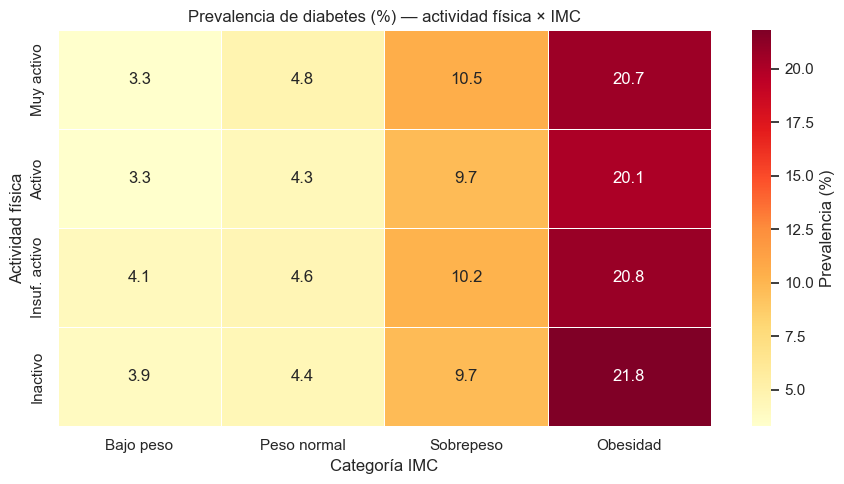

In [13]:
# Visualización — heatmap de prevalencia por actividad física x IMC
pivot = resultado_pacat_bmi.pivot(
    index='actividad_fisica',
    columns='categoria_imc',
    values='prevalencia_pct'
)

# Reordenar filas y columnas por severidad clínica
orden_filas = ['Muy activo', 'Activo', 'Insuf. activo', 'Inactivo']
orden_cols  = ['Bajo peso', 'Peso normal', 'Sobrepeso', 'Obesidad']
pivot = pivot.reindex(index=orden_filas, columns=orden_cols)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Prevalencia (%)'}
)
ax.set_title('Prevalencia de diabetes (%) — actividad física × IMC')
ax.set_xlabel('Categoría IMC')
ax.set_ylabel('Actividad física')
plt.tight_layout()
plt.show()

## 3. Comparativa de comorbilidades

Proporción de cada comorbilidad en población diabética vs no diabética.
Las variables binarias CDC usan la convención `1=Sí / 2=No` — se recodifican
a `1/0` dentro de la query para calcular medias directamente.

`BPHIGH4` es nominal — solo el valor `1` (hipertensión confirmada) se considera positivo.

In [15]:
# Proporción de comorbilidades por clase — recodificación CDC 1=Sí→1, 2=No→0
# Los valores -1 se excluyen del denominador con NULLIF para no distorsionar las medias
resultado_comorbilidades = con.execute("""
    SELECT
        CASE WHEN DIABETE3 = 1.0 THEN 'Diabético' ELSE 'No diabético' END AS clase,
        ROUND(AVG(CASE WHEN HAVARTH3 != -1.0 THEN CASE WHEN HAVARTH3 = 1.0 THEN 1 ELSE 0 END END) * 100, 1) AS pct_artritis,
        ROUND(AVG(CASE WHEN ADDEPEV2 != -1.0 THEN CASE WHEN ADDEPEV2 = 1.0 THEN 1 ELSE 0 END END) * 100, 1) AS pct_depresion,
        ROUND(AVG(CASE WHEN BPHIGH4  != -1.0 THEN CASE WHEN BPHIGH4  = 1.0 THEN 1 ELSE 0 END END) * 100, 1) AS pct_hipertension,
        ROUND(AVG(CASE WHEN BLOODCHO != -1.0 THEN CASE WHEN BLOODCHO = 1.0 THEN 1 ELSE 0 END END) * 100, 1) AS pct_colesterol,
        ROUND(AVG(CASE WHEN SMOKE100 != -1.0 THEN CASE WHEN SMOKE100 = 1.0 THEN 1 ELSE 0 END END) * 100, 1) AS pct_tabaco
    FROM brfss
    GROUP BY DIABETE3
    ORDER BY DIABETE3
""").df()

print('-' * 75)
print(f"{'Clase':<15} {'Artritis':>10} {'Depresión':>10} {'Hiperten.':>10} {'Colesterol':>11} {'Tabaco':>8}")
print('-' * 75)
for _, row in resultado_comorbilidades.iterrows():
    print(
        f"{row['clase']:<15} "
        f"{row['pct_artritis']:>9.1f}% "
        f"{row['pct_depresion']:>9.1f}% "
        f"{row['pct_hipertension']:>9.1f}% "
        f"{row['pct_colesterol']:>10.1f}% "
        f"{row['pct_tabaco']:>7.1f}%"
    )
print('-' * 75)

---------------------------------------------------------------------------
Clase             Artritis  Depresión  Hiperten.  Colesterol   Tabaco
---------------------------------------------------------------------------
Diabético            49.5%      23.8%      73.2%       98.0%    49.8%
No diabético         28.2%      16.6%      32.2%       88.3%    40.2%
---------------------------------------------------------------------------


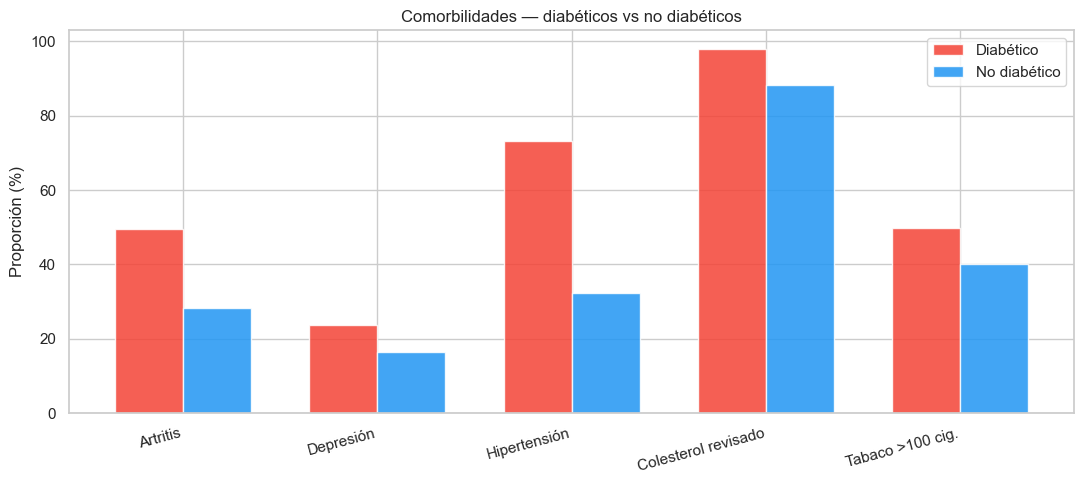

In [16]:
# Visualización comparativa de comorbilidades entre clases
comorbilidades = ['pct_artritis', 'pct_depresion', 'pct_hipertension', 'pct_colesterol', 'pct_tabaco']
etiquetas      = ['Artritis', 'Depresión', 'Hipertensión', 'Colesterol revisado', 'Tabaco >100 cig.']

diabeticos    = resultado_comorbilidades[resultado_comorbilidades['clase'] == 'Diabético'][comorbilidades].values[0]
no_diabeticos = resultado_comorbilidades[resultado_comorbilidades['clase'] == 'No diabético'][comorbilidades].values[0]

x      = range(len(etiquetas))
ancho  = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - ancho/2 for i in x], diabeticos,    ancho, label='Diabético',    color='#F44336', alpha=0.85)
ax.bar([i + ancho/2 for i in x], no_diabeticos, ancho, label='No diabético', color='#2196F3', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(etiquetas, rotation=15, ha='right')
ax.set_ylabel('Proporción (%)')
ax.set_title('Comorbilidades — diabéticos vs no diabéticos')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Resumen de la ejecución

In [17]:
# Resumen de los hallazgos principales del notebook
d  = resultado_comorbilidades[resultado_comorbilidades['clase'] == 'Diabético'].iloc[0]
nd = resultado_comorbilidades[resultado_comorbilidades['clase'] == 'No diabético'].iloc[0]

# Variable continua con mayor delta absoluto
mayor_delta = resultado_delta.iloc[0]

print('=' * 60)
print('RESUMEN — FACTORES DE RIESGO MODIFICABLES')
print('=' * 60)
print(f"  Mayor delta dieta/ejercicio : {mayor_delta['variable']} ({mayor_delta['delta']:+.3f})")
print(f"  Hipertensión en diabéticos  : {d['pct_hipertension']}% vs {nd['pct_hipertension']}% (no diabéticos)")
print(f"  Artritis en diabéticos      : {d['pct_artritis']}% vs {nd['pct_artritis']}% (no diabéticos)")
print(f"  Depresión en diabéticos     : {d['pct_depresion']}% vs {nd['pct_depresion']}% (no diabéticos)")
print('=' * 60)
print('Siguiente paso: 03_advanced_sql.ipynb')

RESUMEN — FACTORES DE RIESGO MODIFICABLES
  Mayor delta dieta/ejercicio : Verdura (porciones/día) (-0.175)
  Hipertensión en diabéticos  : 73.2% vs 32.2% (no diabéticos)
  Artritis en diabéticos      : 49.5% vs 28.2% (no diabéticos)
  Depresión en diabéticos     : 23.8% vs 16.6% (no diabéticos)
Siguiente paso: 03_advanced_sql.ipynb
